## PCA

#### Task 1: Exploratory Data Analysis

Load Data

In [7]:
import pandas as pd
import numpy as np

df = pd.read_csv(r"C:\Users\suraj\OneDrive\Desktop\data sets\wine.csv")
print(df.head())


   Type  Alcohol  Malic   Ash  Alcalinity  Magnesium  Phenols  Flavanoids  \
0     1    14.23   1.71  2.43        15.6        127     2.80        3.06   
1     1    13.20   1.78  2.14        11.2        100     2.65        2.76   
2     1    13.16   2.36  2.67        18.6        101     2.80        3.24   
3     1    14.37   1.95  2.50        16.8        113     3.85        3.49   
4     1    13.24   2.59  2.87        21.0        118     2.80        2.69   

   Nonflavanoids  Proanthocyanins  Color   Hue  Dilution  Proline  
0           0.28             2.29   5.64  1.04      3.92     1065  
1           0.26             1.28   4.38  1.05      3.40     1050  
2           0.30             2.81   5.68  1.03      3.17     1185  
3           0.24             2.18   7.80  0.86      3.45     1480  
4           0.39             1.82   4.32  1.04      2.93      735  


In [8]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB
None


In [9]:
print(df.describe)

<bound method NDFrame.describe of      Type  Alcohol  Malic   Ash  Alcalinity  Magnesium  Phenols  Flavanoids  \
0       1    14.23   1.71  2.43        15.6        127     2.80        3.06   
1       1    13.20   1.78  2.14        11.2        100     2.65        2.76   
2       1    13.16   2.36  2.67        18.6        101     2.80        3.24   
3       1    14.37   1.95  2.50        16.8        113     3.85        3.49   
4       1    13.24   2.59  2.87        21.0        118     2.80        2.69   
..    ...      ...    ...   ...         ...        ...      ...         ...   
173     3    13.71   5.65  2.45        20.5         95     1.68        0.61   
174     3    13.40   3.91  2.48        23.0        102     1.80        0.75   
175     3    13.27   4.28  2.26        20.0        120     1.59        0.69   
176     3    13.17   2.59  2.37        20.0        120     1.65        0.68   
177     3    14.13   4.10  2.74        24.5         96     2.05        0.76   

     Nonflavanoid

Distribution Plots

array([[<Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
        <Axes: ylabel='Density'>, <Axes: ylabel='Density'>],
       [<Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
        <Axes: ylabel='Density'>, <Axes: ylabel='Density'>],
       [<Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
        <Axes: ylabel='Density'>, <Axes: ylabel='Density'>],
       [<Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
        <Axes: ylabel='Density'>, <Axes: ylabel='Density'>]], dtype=object)

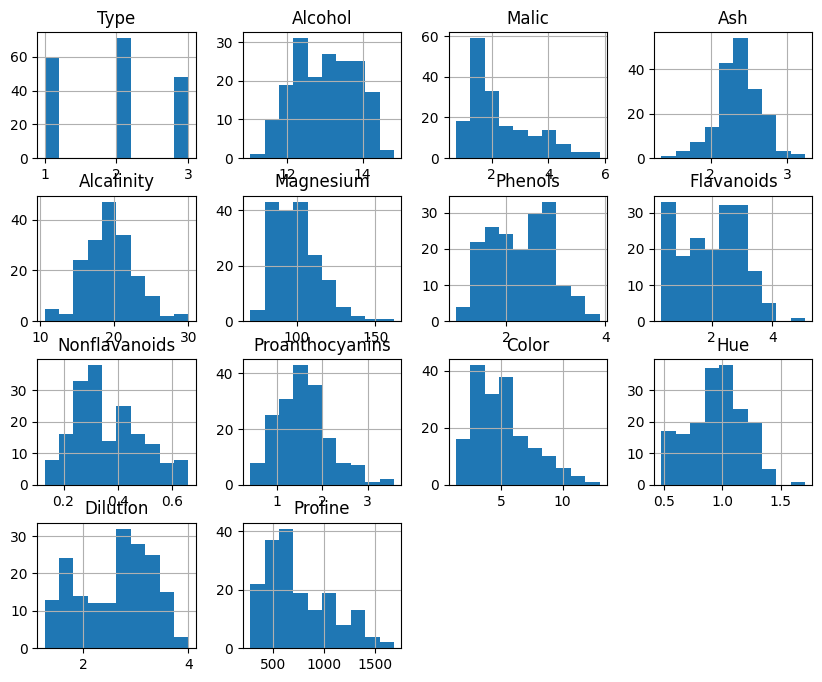

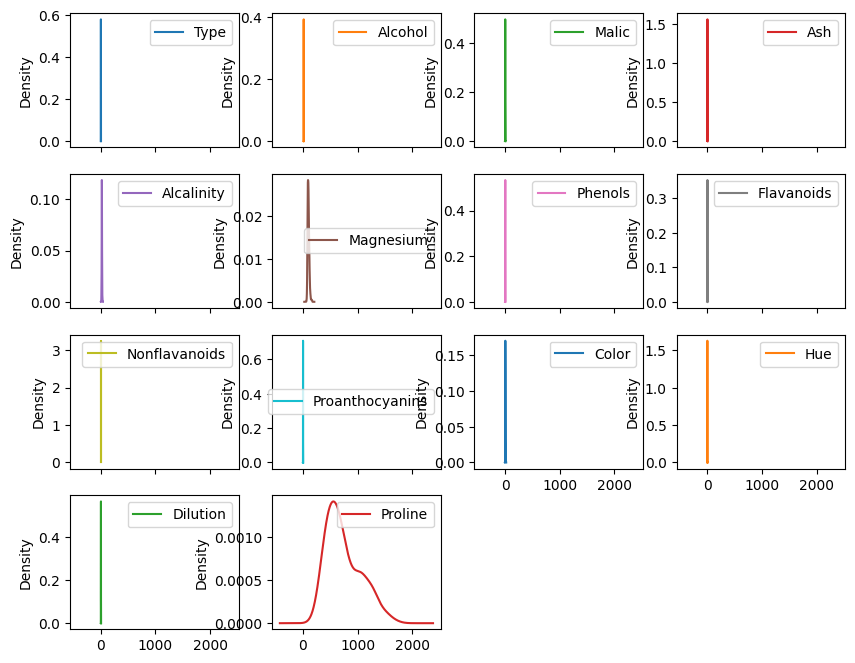

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

#### Histogram
df.hist(figsize=(10,8))

#### Boxplot
sns.boxplot(data=df.select_dtypes(include=['number']))
plt.xticks(rotation=45)

#### Density plot
df.plot(kind='density', subplots=True,layout=(4,4),  figsize=(10,8))

Correlation Heatmap

Text(0.5, 1.0, 'Correlation Matrix')

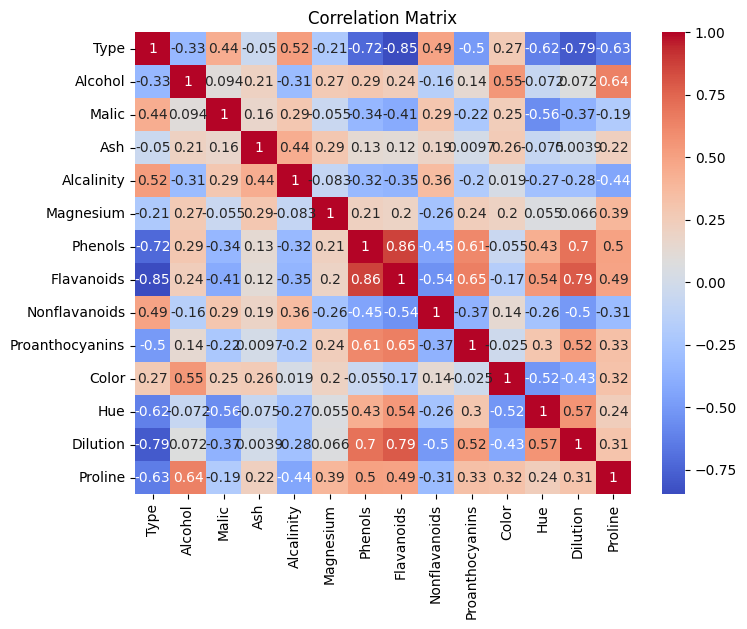

In [11]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")

#### Task 2: PCA (Dimensionality Reduction)

Standardization

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.select_dtypes(include=['number']))

Apply PCA

In [13]:
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

Scree Plot

Text(0.5, 1.0, 'Scree Plot')

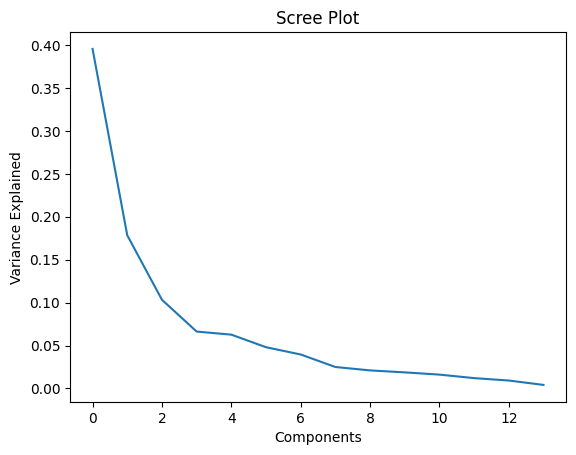

In [14]:
plt.plot(pca.explained_variance_ratio_)
plt.xlabel("Components")
plt.ylabel("Variance Explained")
plt.title("Scree Plot")

#### Task 3: Clustering

K-Means

In [15]:

from sklearn.cluster import KMeans


In [29]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.select_dtypes(include=['number']))

# KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Add result
df['Cluster'] = clusters

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")
df.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline,Cluster
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,2
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,2
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,2
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,2
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,2


 Visualization

Text(0.5, 1.0, 'Clusters (Original Data)')

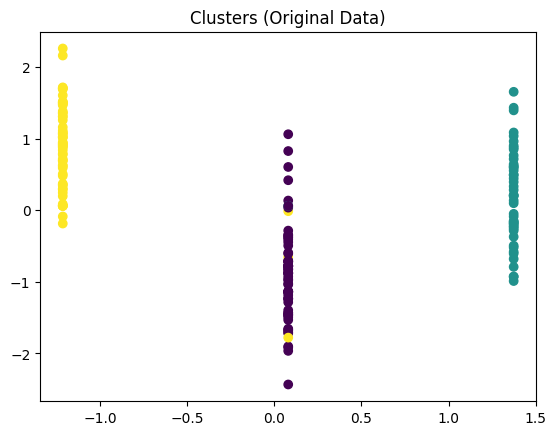

In [17]:
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=clusters)
plt.title("Clusters (Original Data)")

Evaluation

In [18]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

print("Silhouette:", silhouette_score(X_scaled, clusters))
print("DB Index:", davies_bouldin_score(X_scaled, clusters))

Silhouette: 0.30648398324833453
DB Index: 1.315707552261773


#### Task 4: Clustering (PCA Data)

 Apply K-Means on PCA

In [26]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")
kmeans_pca = KMeans(n_clusters=3, random_state=42)
clusters_pca = kmeans_pca.fit_predict(X_pca)


Visualization

Text(0.5, 1.0, 'Clusters (PCA Data)')

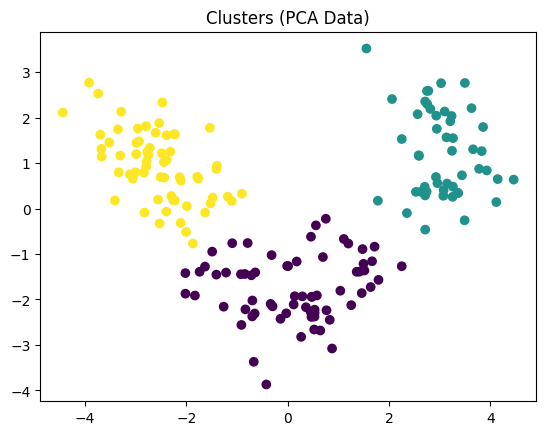

In [23]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters_pca)
plt.title("Clusters (PCA Data)")

Evaluation

In [24]:
print("Silhouette (PCA):", silhouette_score(X_pca, clusters_pca))
print("DB Index (PCA):", davies_bouldin_score(X_pca, clusters_pca))

Silhouette (PCA): 0.30648398324833437
DB Index (PCA): 1.3157075522617734


#### Task 5: Comparison & Analysis

ompare Results
Metric	                  Original Data	             PCA Data
Silhouette Score	      Higher/Lower	             Higher/Lower
DB Index	              Higher/Lower	             Lower/Better

#### Task 6: Conclusion & Insights

PCA helps reduce dimensionality and improves clustering performance by removing noise and redundant features. Clustering on PCA-transformed data often produces better-separated clusters with improved evaluation metrics. However, some information loss may occur. Therefore, PCA is recommended when dealing with high-dimensional data, while original data clustering is suitable when feature interpretability is important.